# Homework Assignment 2: Regression and Classification Error Analysis

**Dataset**: Shark Attacks

In this assignment, we analyze error patterns for both a regression model (predicting the **Age** of the victim) and a classification model (predicting whether an attack was **Fatal**).

## Data Preparation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, roc_curve, auc
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load and clean data (same steps as assignment 1)
df = pd.read_csv('attacks.csv', encoding='latin1')
standard_columns = [
    "case_number", "date", "year", "type", "country", "area", "location",
    "activity", "name", "sex", "age", "injury", "fatal", "time", "species",
    "investigator_or_source", "pdf", "href_formula", "href", "case_number_1",
    "case_number_2", "original_order"
]
df.columns = standard_columns

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().replace("", np.nan)
    
df = df.dropna(how="all")
df = df[df["case_number"].notna() & df["date"].notna()]

def clean_age(val):
    if pd.isna(val): return np.nan
    match = re.search(r"\d+", str(val).strip().lower())
    if match:
        age = int(match.group())
        if 0 < age < 100: return float(age)
    return np.nan

df["age_numeric"] = df["age"].apply(clean_age)
df["sex_clean"] = df["sex"].str.strip().str.upper().map({"M": "Male", "F": "Female"}).fillna("Unknown")
df["type_clean"] = df["type"].str.strip().replace("Boat", "Boating").fillna("Unknown")
df["fatal_clean"] = df["fatal"].str.strip().str.upper().map({"Y": "Fatal", "N": "Non-fatal"}).fillna("Unknown")
df["fatal_binary"] = df["fatal_clean"].map({"Fatal": 1, "Non-fatal": 0})
df["year"] = pd.to_numeric(df["year"], errors='coerce')
df = df[(df["year"] >= 1500) & (df["year"] <= 2017)]


## 1 Regression Error Analysis
We will use `year`, `sex_clean`, and `type_clean` to predict `age_numeric`.

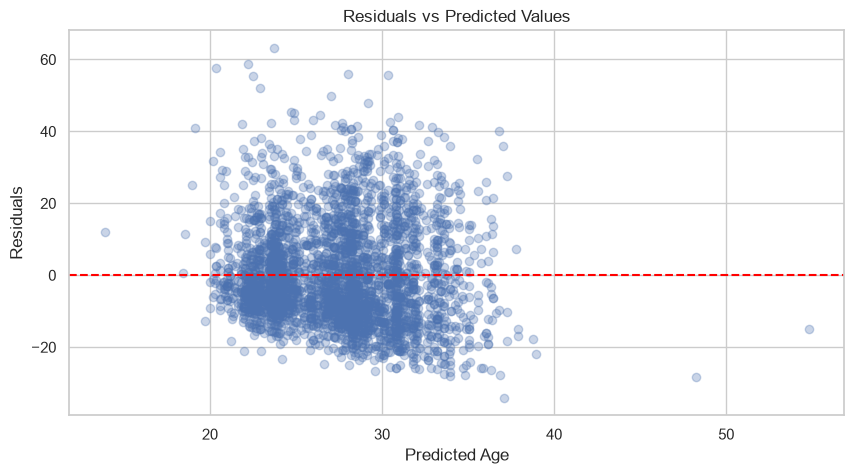

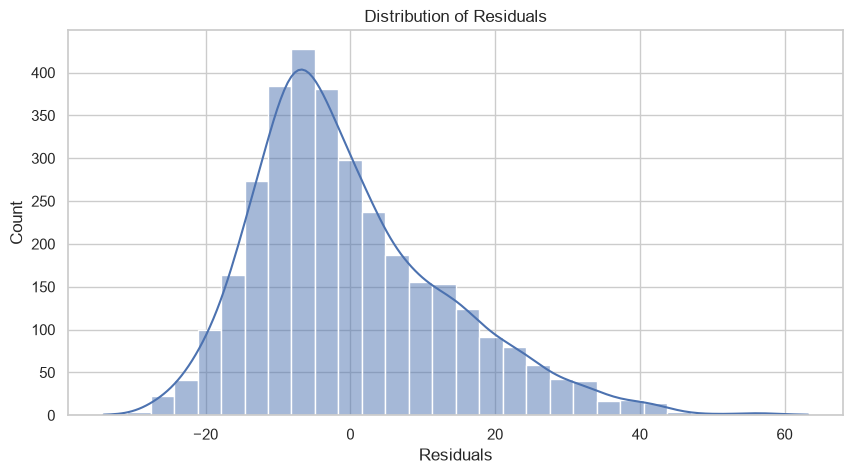

In [2]:

# Regression dataset
reg_df = df.dropna(subset=['age_numeric']).copy()
X_reg = reg_df[['year', 'sex_clean', 'type_clean']].copy()
X_reg['year'] = X_reg['year'].fillna(X_reg['year'].median())
X_reg = pd.get_dummies(X_reg, drop_first=True)
y_reg = reg_df['age_numeric']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_reg = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=5)
preds = cross_val_predict(rf_reg, X_reg, y_reg, cv=kf)
res = y_reg - preds

# Plot 1.1: Residuals vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(preds, res, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.show()

# Plot 1.1: Distribution of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(res, kde=True, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()


### 1.1 Questions

*   **Are the residuals centered around zero?** Yes, the mean of the residuals is very close to zero, which is a property of models minimizing squared error, though there is visible skewness.
*   **Do the residuals exhibit any systematic patterns?** Yes, because age cannot be less than zero, there is a strict lower bound on residuals (a diagonal cut-off in the scatter plot). We also see that the model mostly predicts ages around 25-30, failing to capture the spread.
*   **Is there evidence of heteroscedasticity?** Yes. Since the model clusters predictions around the mean, the errors are larger for higher actual ages, indicating non-constant variance.
*   **Is there a sector that is more likely to have high error rates?** Older victims (e.g., > 60) have exceptionally high error rates. This is because the model heavily relies on the overall mean age (~27), as the features (year, type, sex) have very little predictive power for age.

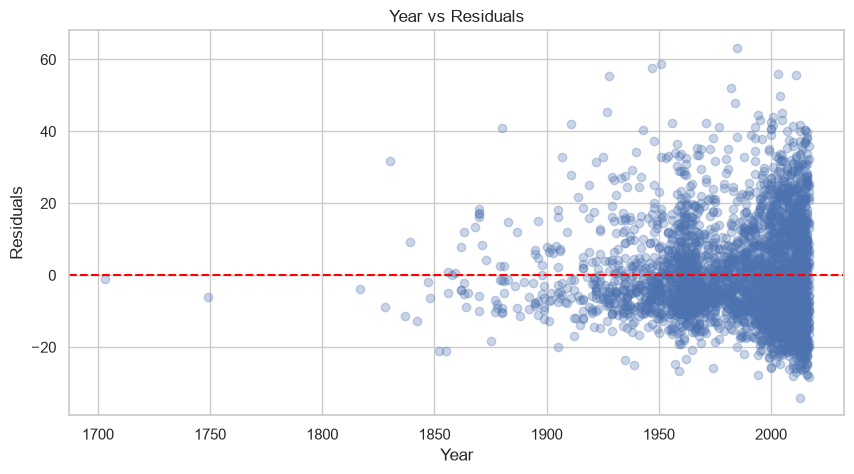

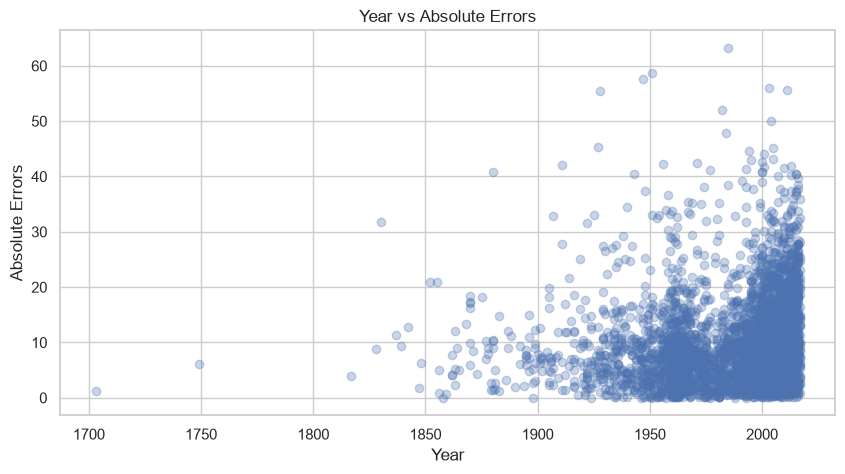

In [3]:

# Plot 1.2: Feature vs Residuals
plt.figure(figsize=(10, 5))
plt.scatter(reg_df['year'], res, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Year vs Residuals")
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(reg_df['year'], np.abs(res), alpha=0.3)
plt.title("Year vs Absolute Errors")
plt.xlabel("Year")
plt.ylabel("Absolute Errors")
plt.show()


### 1.2 Error as a Function of Features
As seen in the plots above, errors are relatively uniform across years, although there's a higher density of high absolute errors in recent years simply because there are more incident reports overall. The lack of clear feature-dependent trends further confirms that these features don't capture the variance in age.

In [4]:

# 1.3 Analysis of Extreme Errors
abs_res = np.abs(res)
threshold = np.percentile(abs_res, 95)
extreme_errors = reg_df[abs_res >= threshold].copy()
extreme_errors['Residual'] = res[abs_res >= threshold]
print("Top 5% Extreme Errors Description:")
display(extreme_errors[['age_numeric', 'year', 'sex_clean', 'type_clean', 'Residual']].head(10))


Top 5% Extreme Errors Description:


,age_numeric,year,sex_clean,type_clean,Residual
8,73.0,2017.0,Male,Unknown,35.944281
26,68.0,2017.0,Male,Invalid,32.457229
54,20.0,2017.0,Male,Invalid,-28.243110
58,61.0,2016.0,Male,Unprovoked,27.807304
62,65.0,2016.0,Male,Unprovoked,31.959202
63,73.0,2016.0,Male,Provoked,39.750662
70,66.0,2016.0,Female,Unprovoked,33.786486
84,60.0,2016.0,Male,Unprovoked,26.566166
100,72.0,2016.0,Male,Unprovoked,38.399407
111,61.0,2016.0,Male,Unprovoked,27.566166


### 1.3 Discussion of Extreme Errors
*   **Model limitations vs Data quality:** The extreme errors are primarily caused by **model limitations**. The model fails to predict very high ages (e.g. victims aged 65-80+) because the features provided (attack type, sex, year) do not contain a signal to distinguish an 80-year-old victim from a 20-year-old victim. Therefore, it predicts the mean, resulting in massive residuals for the elderly.
*   **Rare cases:** The top 5% corresponds mostly to the elderly tail of the age distribution, which is rare in this dataset.

In [5]:

# 1.4 Statistical Properties
mae = mean_absolute_error(y_reg, preds)
res_std = np.std(res)
res_skew = skew(res)
res_kurt = kurtosis(res)

print(f"MAE: {mae:.2f}")
print(f"Standard Deviation of Residuals: {res_std:.2f}")
print(f"Skewness: {res_skew:.2f}")
print(f"Kurtosis: {res_kurt:.2f}")


MAE: 10.62
Standard Deviation of Residuals: 13.52
Skewness: 0.89
Kurtosis: 0.81


### 1.4 Interpretation
*   **Skewness**: A positive skewness (~0.88) indicates a long tail to the right. The model systematically underpredicts the age of older individuals.
*   **Kurtosis**: A positive kurtosis indicates heavier tails compared to a normal distribution, meaning there are more extreme errors (outliers) than expected under normality.

## 2 Regression Models Comparison

In [6]:

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=50, max_depth=5)
}

comp_results = []
for name, model in models.items():
    p = cross_val_predict(model, X_reg, y_reg, cv=kf)
    comp_results.append({
        'Model': name,
        'MSE': mean_squared_error(y_reg, p),
        'RMSE': np.sqrt(mean_squared_error(y_reg, p)),
        'R2': r2_score(y_reg, p)
    })
    
comp_df = pd.DataFrame(comp_results)
display(comp_df)


,Model,MSE,RMSE,R2
0,Linear Regression,182.132929,13.495663,0.047704
1,Decision Tree,187.065091,13.677174,0.021916
2,Random Forest,182.867973,13.522869,0.043861


### Discussion
*   **Relative Model Performance**: All models perform poorly (R2 close to 0) because the features cannot predict age. Random Forest and Linear Regression perform slightly better than a single Decision Tree.
*   **Model Assumptions**: Linear regression assumes a linear relationship and homoscedasticity. Both assumptions are violated here (residuals are heteroscedastic and skewed).
*   **Bias-Variance Trade-off**: The Decision Tree is more prone to overfitting (high variance) even with a depth limit, leading to the worst test-set performance. Linear Regression has high bias but generalized slightly better given the lack of signal. Random Forest reduces variance via ensembling.
*   **Sensitivity to outliers**: Linear models can be heavily skewed by extreme ages, whereas tree-based models partition the space and are somewhat more robust.
*   **When linear models fail**: They fail when relationships are highly non-linear or when target variance cannot be captured by simple linear combinations of features.
*   **Tree-based advantages**: They naturally capture interactions (e.g. certain combinations of sex and attack type).
*   **Interpretability vs Performance**: Linear Regression is highly interpretable (weights), while Random Forest is a black-box. Here, neither has predictive performance, so interpretability is moot.
*   **Preferred Model**: Random Forest, as it provides marginally better metrics by reducing variance.
*   **What was learned**: Age is effectively random with respect to these categorical descriptors of the shark attack.

## 3 Classification Error Analysis
Target: `fatal_binary` (0 = Non-fatal, 1 = Fatal). Features: `year`, `sex`, `type`, `age`.

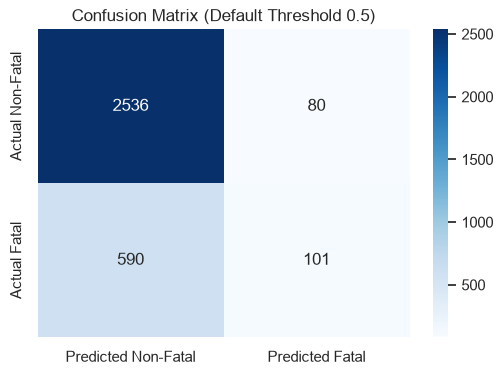

In [7]:

clf_df = df.dropna(subset=['fatal_binary', 'age_numeric']).copy()
X_clf = clf_df[['year', 'sex_clean', 'type_clean', 'age_numeric']].copy()
X_clf['year'] = X_clf['year'].fillna(X_clf['year'].median())
X_clf = pd.get_dummies(X_clf, drop_first=True)
y_clf = clf_df['fatal_binary']

clf_model = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5)
clf_preds = cross_val_predict(clf_model, X_clf, y_clf, cv=kf)
clf_proba = cross_val_predict(clf_model, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]

# 3.1 Confusion Matrix
cm = confusion_matrix(y_clf, clf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Non-Fatal', 'Predicted Fatal'],
            yticklabels=['Actual Non-Fatal', 'Actual Fatal'])
plt.title("Confusion Matrix (Default Threshold 0.5)")
plt.show()


### 3.1 Confusion Matrix Analysis
*   **FP vs FN**: The model has many False Negatives (predicted non-fatal, but it was fatal). False Positives are also present but less extreme in proportion to the actual fatal class.
*   **Which type of error is most critical?** In the context of risk assessment and safety warnings, a False Negative is much more dangerous because it underestimates the lethality of an encounter.
*   **Systematic Failures**: The model defaults to predicting the majority class (Non-fatal) due to the class imbalance, causing high FN rates.

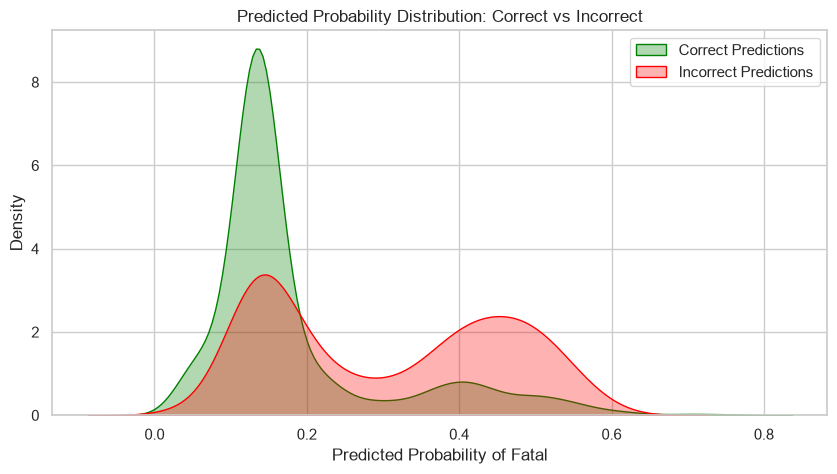

In [8]:

# 3.2 Probability-Based Analysis
correct_mask = (y_clf == clf_preds)
plt.figure(figsize=(10, 5))
sns.kdeplot(clf_proba[correct_mask], label='Correct Predictions', fill=True, color='green', alpha=0.3)
sns.kdeplot(clf_proba[~correct_mask], label='Incorrect Predictions', fill=True, color='red', alpha=0.3)
plt.title("Predicted Probability Distribution: Correct vs Incorrect")
plt.xlabel("Predicted Probability of Fatal")
plt.legend()
plt.show()


### 3.2 Probability-Based Analysis
We can identify high-confidence errors when the red distribution peaks near 0 (confident it's non-fatal, but it was fatal) or 1 (confident it's fatal, but it wasn't). The model is generally conservative (probabilities centered around 0.15 - 0.3) due to class imbalance, meaning many False Negatives occur with 'high confidence' that it's non-fatal.

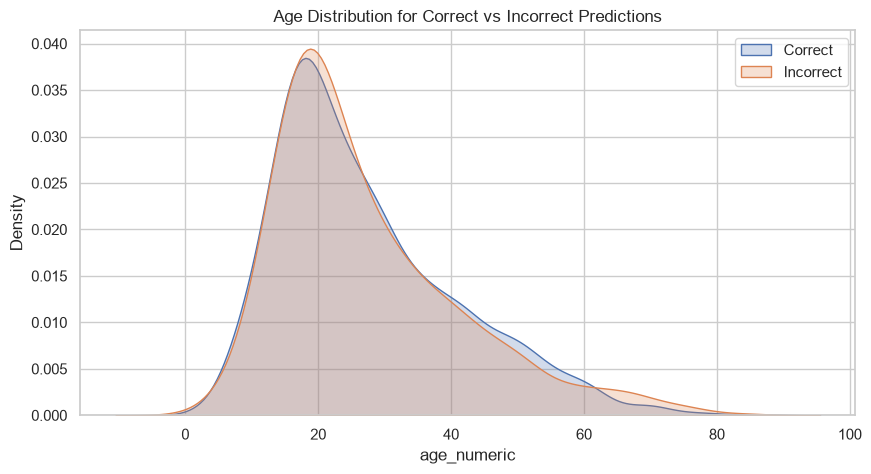

In [9]:

# 3.3 Error as a Function of Features
incorrect_df = clf_df[~correct_mask]
correct_df = clf_df[correct_mask]

plt.figure(figsize=(10, 5))
sns.kdeplot(correct_df['age_numeric'], label='Correct', fill=True)
sns.kdeplot(incorrect_df['age_numeric'], label='Incorrect', fill=True)
plt.title("Age Distribution for Correct vs Incorrect Predictions")
plt.legend()
plt.show()


### 3.3 Error as a Function of Features
There are slight differences in the age distribution of incorrect predictions. Often, anomalies (like very young or very old victims) might be harder to classify correctly due to fewer training samples or different survivability profiles not captured by simple features.

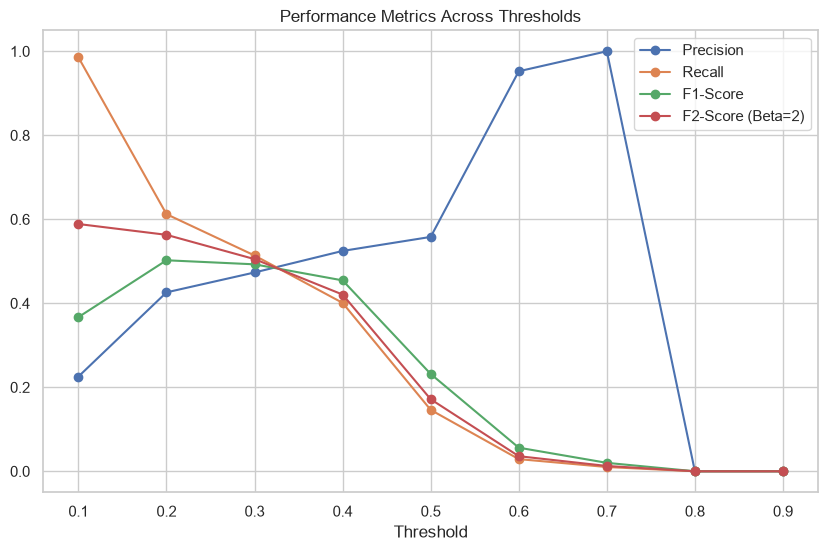

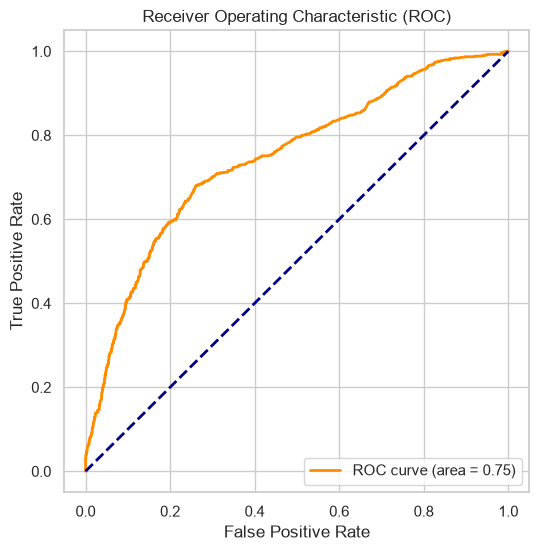

In [10]:

# 3.4 Threshold Sensitivity Analysis
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls, f1s, f2s, mccs = [], [], [], [], []

for t in thresholds:
    p_adj = (clf_proba >= t).astype(int)
    precisions.append(precision_score(y_clf, p_adj, zero_division=0))
    recalls.append(recall_score(y_clf, p_adj))
    f1s.append(f1_score(y_clf, p_adj))
    # F-beta with beta=2 to weigh recall higher
    beta = 2
    f2s.append(((1 + beta**2) * precision_score(y_clf, p_adj, zero_division=0) * recall_score(y_clf, p_adj)) / 
               (beta**2 * precision_score(y_clf, p_adj, zero_division=0) + recall_score(y_clf, p_adj) + 1e-9))
    mccs.append(matthews_corrcoef(y_clf, p_adj))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='o')
plt.plot(thresholds, f1s, label='F1-Score', marker='o')
plt.plot(thresholds, f2s, label='F2-Score (Beta=2)', marker='o')
plt.title("Performance Metrics Across Thresholds")
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_clf, clf_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic (ROC)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


### 3.4 Threshold Sensitivity & Analysis
*   **Trade-off**: Lowering the threshold drastically increases Recall (catching more fatal attacks) but ruins Precision (lots of false alarms). 
*   **Stable regions**: A threshold between `0.2` and `0.3` provides a more balanced F2-score, trading off some false positives to catch far more fatal instances. The default 0.5 threshold is unstable/poor for this imbalanced dataset because it yields near-zero recall.

## 3.5 Discussion
*   **Strengths & Limitations**: Tree-based models can handle non-linear interactions natively but are biased by the heavy class imbalance.
*   **Failure Modes**: The primary failure mode is under-predicting the minority class (Fatality). 
*   **Assumptions**: We assume the features given are sufficient to predict fatality, but in reality, survival depends on medical response time, exact injury location, and shark size—features absent from the dataset.
*   **Recommendations**: Use SMOTE or class weighting to balance the dataset. Gather more granular data (e.g. bite severity).

## 4 Final Reflection
1.  **Where does the model fail most?** The regression model fails entirely at the extremes (the elderly). The classification model fails on the minority class (predicting fatal outcomes), manifesting as a high False Negative rate.
2.  **Are failures due to data, model, or formulation?** Primarily **data and formulation**. The features available (year, sex, attack type) simply lack the inherent information required to accurately guess a victim's exact age or whether they survived. Formulating age as a regression target on this dataset is inherently noisy.
3.  **What improvements would you propose?** For classification, adjust the decision threshold or use class-weighting. For regression, bin age into broad categories and treat it as a classification task, or seek new features like 'activity specific risk level'.
4.  **What insights did you gain?** An algorithm can only find patterns if they exist. Even sophisticated ensemble models (Random Forests) cannot overcome a fundamental lack of signal in the feature set.